In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://www.thesportsdb.com/api/v1/json/3/lookuptable.php?l=4328&s=2023-2024"
response = requests.get(url).json()

In [3]:
df = pd.DataFrame(response["table"])
df = df[["strTeam", "intPlayed", "intWin", "intGoalsFor", "intPoints"]].copy()

In [4]:
df["intWin"] = pd.to_numeric(df["intWin"])
df["intGoalsFor"] = pd.to_numeric(df["intGoalsFor"])
df["intPoints"] = pd.to_numeric(df["intPoints"])

In [5]:
df.head()

,strTeam,intPlayed,intWin,intGoalsFor,intPoints
0,Manchester City,38,28,96,91
1,Arsenal,38,28,91,89
2,Liverpool,38,24,86,82
3,Aston Villa,38,20,76,68
4,Tottenham,38,20,74,66


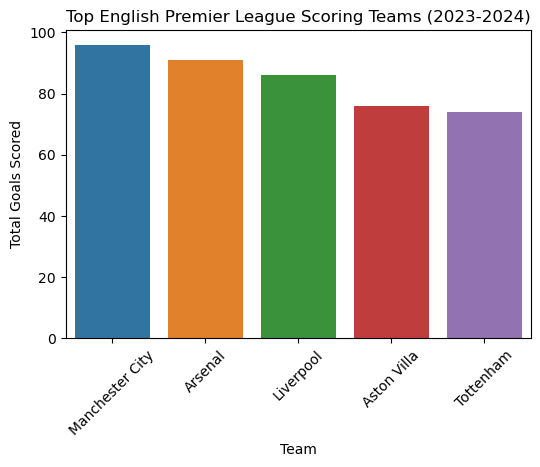

In [6]:
plt.figure(figsize=(6, 4))
top_scorers = df.sort_values(by="intGoalsFor", ascending=False).head(10)

sns.barplot(
    data=top_scorers, 
    x="strTeam", 
    y="intGoalsFor", 
    hue="strTeam", 
    legend=False
)

plt.title("Top English Premier League Scoring Teams (2023-2024)")
plt.xlabel("Team")
plt.ylabel("Total Goals Scored")
plt.xticks(rotation=45)
plt.show()

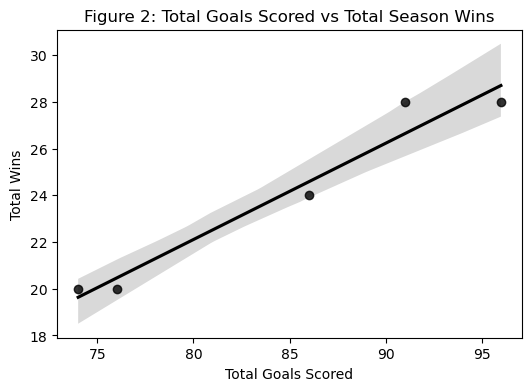

In [7]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x="intGoalsFor", y="intWin", color="black")

plt.title("Total Goals Scored vs Total Season Wins")
plt.xlabel("Total Goals Scored")
plt.ylabel("Total Wins")
plt.show()